# Project 1 - NLP Automated Customer Reviews
## Step 0 (cleaning) + Task 1 baseline + Task 2 clustering

Subha & Rayhan

**Everything in this notebook runs on CPU.** No GPU is used, deliberately - the free
Colab GPU allowance is saved for the two steps that genuinely need it: fine-tuning a
transformer for Task 1, and the generative summaries in Task 3.

Dataset: Amazon Product Reviews (Datafiniti), `1429_1.csv` - 34,660 reviews, 21 columns.

## Setup

In [4]:
%matplotlib inline

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

from pathlib import Path

# the raw CSV sits in a different folder depending on the checkout
DATA = next(c for c in [Path("data/1429_1.csv"),
                        Path("../datasets/1429_1.csv"),
                        Path("datasets/1429_1.csv")] if c.exists())
OUT_DIR = DATA.parent            # generated CSVs sit beside the raw one

df = pd.read_csv(DATA, low_memory=False)
print("shape:", df.shape)
df.head(3)

shape: (34660, 21)


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",NaN,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ


# Step 0 - Profiling and cleaning

Both of us must work from the same cleaned file, or our numbers will not be comparable.

In [5]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isnull().sum(),
    "missing_%": (100 * df.isnull().mean()).round(2),
    "unique": df.nunique(),
})
profile.sort_values("missing_%", ascending=False)

,dtype,missing,missing_%,unique
reviews.id,float64,34659,100.00,1
reviews.userProvince,float64,34660,100.00,0
reviews.userCity,float64,34660,100.00,0
reviews.didPurchase,object,34659,100.00,1
reviews.dateAdded,str,10621,30.64,1941
name,str,6760,19.50,48
reviews.doRecommend,object,594,1.71,2
reviews.numHelpful,float64,529,1.53,97
reviews.date,str,39,0.11,1078
reviews.rating,float64,33,0.10,5


In [6]:
# Columns carrying (almost) no information.
#
# The threshold matters: userCity and userProvince are exactly 100% empty, but
# reviews.didPurchase and reviews.id each hold ONE non-null value out of 34,660
# (99.997%). A strict `== 1.0` test would keep two completely useless columns.
empty_cols = [col for col in df.columns if df[col].isnull().mean() > 0.99]

print("columns over 99% empty:")
for col in empty_cols:
    print("   %-24s %.3f%% missing" % (col, 100 * df[col].isnull().mean()))

print()
print("scale of the dataset:")
for col in ["id", "asins", "name", "brand", "categories", "manufacturer"]:
    print("   %-14s %5d unique" % (col, df[col].nunique()))

print()
print("34,660 reviews but only ~42 products. Task 2 clusters PRODUCTS, not")
print("reviews - worth knowing before over-engineering it.")

columns over 99% empty:
   reviews.didPurchase      99.997% missing
   reviews.id               99.997% missing
   reviews.userCity         100.000% missing
   reviews.userProvince     100.000% missing

scale of the dataset:
   id                42 unique
   asins             41 unique
   name              48 unique
   brand              6 unique
   categories        41 unique
   manufacturer       2 unique

34,660 reviews but only ~42 products. Task 2 clusters PRODUCTS, not
reviews - worth knowing before over-engineering it.


## The target variable

star ratings:
   1 star    410    1.2%  
   2 star    402    1.2%  
   3 star   1499    4.3%  ###
   4 star   8541   24.6%  #################
   5 star  23775   68.6%  ################################################


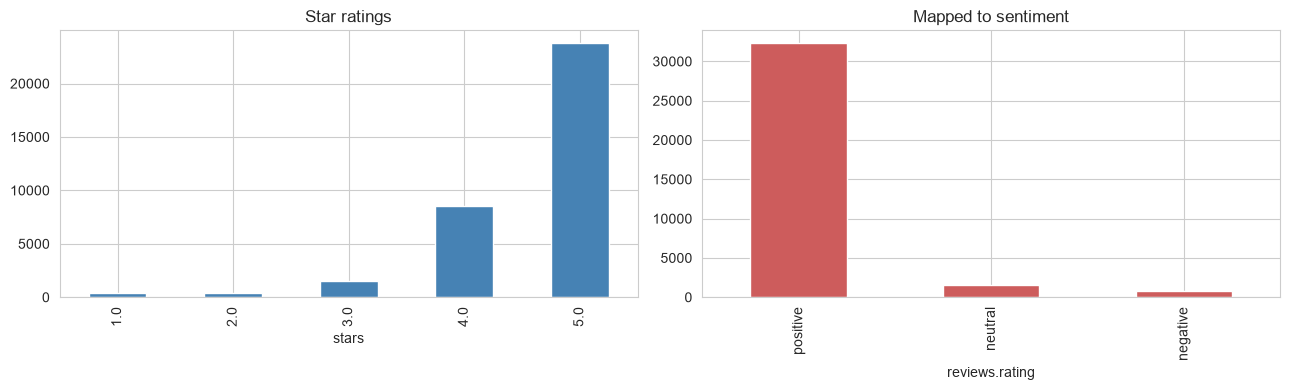


missing ratings    : 33
missing review text: 1


In [7]:
vc = df["reviews.rating"].value_counts().sort_index()

print("star ratings:")
for stars, n in vc.items():
    print("   %d star %6d  %5.1f%%  %s"
          % (stars, n, 100 * n / len(df), "#" * int(70 * n / len(df))))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
vc.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Star ratings")
axes[0].set_xlabel("stars")

sent_preview = df["reviews.rating"].dropna().apply(
    lambda r: "negative" if r <= 2 else ("neutral" if r == 3 else "positive"))
sent_preview.value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Mapped to sentiment")
plt.tight_layout()
plt.show()

print()
print("missing ratings    :", int(df["reviews.rating"].isnull().sum()))
print("missing review text:", int(df["reviews.text"].isnull().sum()))

## Verifying the brief's data-quality warnings

The project README hides a note in an HTML comment: some `name` values have two
product names concatenated, and the same `id` can cover genuinely different products.
Worth checking directly rather than taking on trust.

In [8]:
corrupt = df[df["name"].astype(str).str.contains(r"\r|\n|,,,", regex=True, na=False)]
print("rows with a corrupted name: %d (%.1f%% of the data)"
      % (len(corrupt), 100 * len(corrupt) / len(df)))
print("-> not a rare edge case; almost a third of the dataset")
print()
for name in corrupt["name"].dropna().unique()[:4]:
    print("  ", repr(name[:92]))

print()
print("--- does one id ever cover several product names? ---")
per_id = df.groupby("id")["name"].nunique().sort_values(ascending=False)
print("ids covering more than one name: %d of %d" % ((per_id > 1).sum(), len(per_id)))
print()
worst = per_id.index[0]
print("worst offender, id =", worst)
for name in df[df["id"] == worst]["name"].dropna().unique()[:6]:
    print("   -", str(name).replace("\r", " ").replace("\n", " ")[:78])

rows with a corrupted name: 10975 (31.7% of the data)
-> not a rare edge case; almost a third of the dataset

   'Amazon Kindle Lighted Leather Cover,,,\r\nAmazon Kindle Lighted Leather Cover,,,'
   'Amazon Kindle Lighted Leather Cover,,,\r\nKindle Keyboard,,,'
   'Kindle Keyboard,,,\r\nKindle Keyboard,,,'
   'Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,'

--- does one id ever cover several product names? ---
ids covering more than one name: 13 of 42

worst offender, id = AVpfl8cLLJeJML43AE3S
   - Echo (White),,,  Echo (White),,,
   - Echo (White),,,  Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers
   - Echo (Black),,,  Echo (Black),,,
   - Echo (Black),,,  Amazon 9W PowerFast Official OEM USB Charger and Power Adapte
   - Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablet
   - Amazon Fire Hd 6 Standing Protective Case(4th Generation - 2014 Release), Caye


### Cleaning decisions

| decision | reason |
|---|---|
| drop columns >99% empty | nothing to learn from them |
| drop rows with no rating or no text | those two columns *are* Task 1; only ~34 rows |
| cut `name` at the first `\r`, `\n` or `,,,` | removes the duplication |
| treat `id` as unreliable | 13 of 42 ids cover more than one product |
| keep `neutral` as its own class | the brief's default mapping - but see the imbalance below |

In [9]:
clean = df.drop(columns=empty_cols).copy()

before = len(clean)
clean = clean.dropna(subset=["reviews.rating", "reviews.text"])
print("dropped %d rows with no rating or no text" % (before - len(clean)))


def clean_name(value):
    """Cut the product name at the first line break or ',,,' and tidy it."""
    if pd.isna(value):
        return value
    return re.split(r"\r|\n|,,,", str(value))[0].strip().strip(",").strip()


clean["product_name"] = clean["name"].apply(clean_name)


def to_sentiment(rating):
    if rating <= 2:
        return "negative"
    if rating == 3:
        return "neutral"
    return "positive"


clean["sentiment"] = clean["reviews.rating"].apply(to_sentiment)

print("distinct product names: %d -> %d after cleaning"
      % (df["name"].nunique(), clean["product_name"].nunique()))
print("final shape:", clean.shape)
print()
counts = clean["sentiment"].value_counts()
print(counts.to_string())
print()
print("IMBALANCE: %.0f positives for every negative" % (counts["positive"] / counts["negative"]))
print("Always answering 'positive' scores %.1f%% accuracy and is useless."
      % (100 * counts["positive"] / counts.sum()))
print("So: report per-class recall and the confusion matrix, never accuracy alone.")

dropped 34 rows with no rating or no text
distinct product names: 48 -> 40 after cleaning
final shape: (34626, 19)

sentiment
positive    32315
neutral      1499
negative      812

IMBALANCE: 40 positives for every negative
Always answering 'positive' scores 93.3% accuracy and is useless.
So: report per-class recall and the confusion matrix, never accuracy alone.


In [10]:
OUT = OUT_DIR / "reviews_clean.csv"
clean.to_csv(OUT, index=False)
print("saved %s  (%d rows, %d columns)" % (OUT, len(clean), clean.shape[1]))
print()
print("Share this file with Rayhan - both of us must model the same rows.")

saved ../datasets/reviews_clean.csv  (34626 rows, 19 columns)

Share this file with Rayhan - both of us must model the same rows.


# TASK 1 - Sentiment analysis (baseline)

TF-IDF + Logistic Regression. No GPU, trains in seconds, and produces the number
a fine-tuned transformer has to beat. Without it there is no way to argue the
transformer was worth its cost.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, balanced_accuracy_score, f1_score)

X = clean["reviews.text"].astype(str)
y = clean["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("train: %d    test: %d" % (len(X_train), len(X_test)))
print()
print("test set composition:")
print(y_test.value_counts().to_string())
print()
print("baseline to beat - always predict 'positive': %.4f"
      % (y_test == "positive").mean())

train: 27700    test: 6926

test set composition:
sentiment
positive    6464
neutral      300
negative     162

baseline to beat - always predict 'positive': 0.9333


In [12]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2),
                             min_df=2, stop_words="english")

X_train_v = vectorizer.fit_transform(X_train)   # fit on TRAIN only - no leakage
X_test_v = vectorizer.transform(X_test)

print("vocabulary:", X_train_v.shape[1], "features")
print("matrix    :", X_train_v.shape, "- %.2f%% non-zero"
      % (100 * X_train_v.nnz / (X_train_v.shape[0] * X_train_v.shape[1])))

vocabulary: 20000 features
matrix    : (27700, 20000) - 0.09% non-zero


### The comparison that matters: with and without `class_weight`

Same model, same features, same split. The only difference is whether the minority
classes are weighted up.

In [13]:
results = {}

for weight in [None, "balanced"]:
    clf = LogisticRegression(max_iter=2000, class_weight=weight, random_state=42)
    clf.fit(X_train_v, y_train)
    pred = clf.predict(X_test_v)
    results[str(weight)] = (clf, pred)

    print("=" * 66)
    print("LogisticRegression, class_weight =", weight)
    print("=" * 66)
    print("accuracy          : %.4f" % accuracy_score(y_test, pred))
    print("balanced accuracy : %.4f" % balanced_accuracy_score(y_test, pred))
    print("macro F1          : %.4f" % f1_score(y_test, pred, average="macro"))
    print()
    print(classification_report(y_test, pred, digits=3))
    print("confusion matrix (rows = true, columns = predicted):")
    print(pd.DataFrame(confusion_matrix(y_test, pred, labels=["negative", "neutral", "positive"]),
                       index=["true neg", "true neu", "true pos"],
                       columns=["pred neg", "pred neu", "pred pos"]).to_string())
    print()

LogisticRegression, class_weight = None
accuracy          : 0.9357
balanced accuracy : 0.3891
macro F1          : 0.4188

              precision    recall  f1-score   support

    negative      0.636     0.130     0.215       162
     neutral      0.462     0.040     0.074       300
    positive      0.939     0.998     0.967      6464

    accuracy                          0.936      6926
   macro avg      0.679     0.389     0.419      6926
weighted avg      0.911     0.936     0.911      6926

confusion matrix (rows = true, columns = predicted):
          pred neg  pred neu  pred pos
true neg        21         6       135
true neu         4        12       284
true pos         8         8      6448

LogisticRegression, class_weight = balanced
accuracy          : 0.8656
balanced accuracy : 0.6197
macro F1          : 0.5251

              precision    recall  f1-score   support

    negative      0.308     0.574     0.401       162
     neutral      0.177     0.390     0.243       30

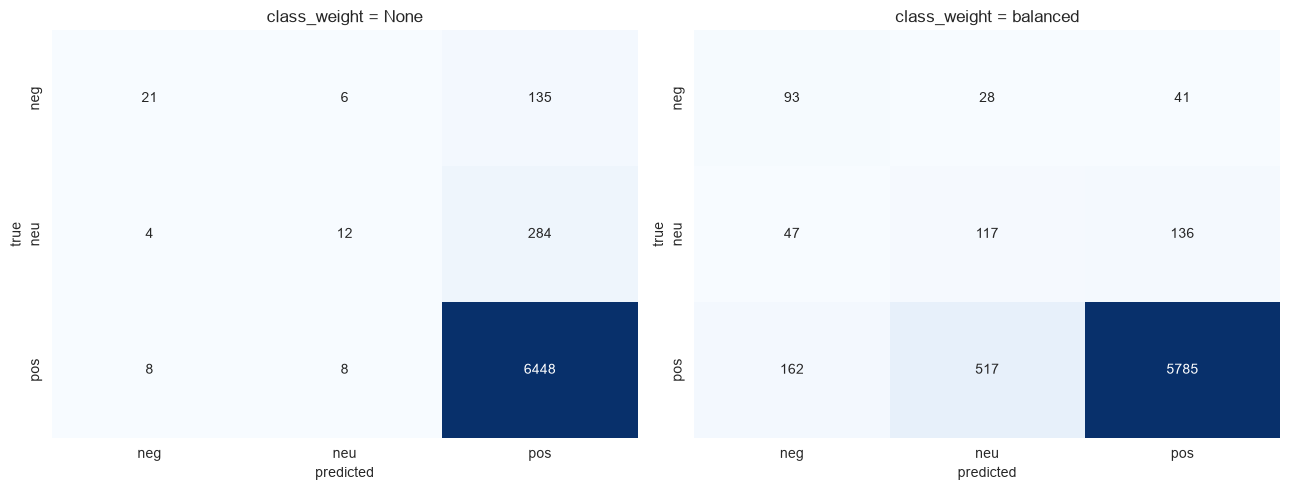

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (label, (clf, pred)) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, pred, labels=["negative", "neutral", "positive"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["neg", "neu", "pos"],
                yticklabels=["neg", "neu", "pos"], cbar=False)
    ax.set_title("class_weight = %s" % label)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
plt.tight_layout()
plt.show()

### Other classical models, for comparison

In [15]:
print("%-34s %8s %10s %9s %9s" % ("model", "acc", "balanced", "macro F1", "neg rec"))
print("-" * 74)

candidates = [
    ("LogisticRegression", LogisticRegression(max_iter=2000, random_state=42)),
    ("LogisticRegression balanced", LogisticRegression(max_iter=2000,
                                                       class_weight="balanced",
                                                       random_state=42)),
    ("LinearSVC", LinearSVC(random_state=42)),
    ("LinearSVC balanced", LinearSVC(class_weight="balanced", random_state=42)),
    ("MultinomialNB", MultinomialNB()),
]

for label, est in candidates:
    est.fit(X_train_v, y_train)
    pred = est.predict(X_test_v)
    cm = confusion_matrix(y_test, pred, labels=["negative", "neutral", "positive"])
    neg_recall = cm[0, 0] / cm[0].sum()
    print("%-34s %8.4f %10.4f %9.4f %9.3f"
          % (label, accuracy_score(y_test, pred),
             balanced_accuracy_score(y_test, pred),
             f1_score(y_test, pred, average="macro"), neg_recall))

print()
print("Read the last two columns, not the first. Accuracy rewards a model for")
print("ignoring the minority classes; negative recall is what a review system")
print("actually needs - missing complaints is the expensive failure.")

model                                   acc   balanced  macro F1   neg rec
--------------------------------------------------------------------------
LogisticRegression                   0.9357     0.3891    0.4188     0.130
LogisticRegression balanced          0.8656     0.6197    0.5251     0.574
LinearSVC                            0.9363     0.4365    0.4805     0.210
LinearSVC balanced                   0.9248     0.5156    0.5413     0.352
MultinomialNB                        0.9333     0.3333    0.3218     0.000

Read the last two columns, not the first. Accuracy rewards a model for
ignoring the minority classes; negative recall is what a review system
actually needs - missing complaints is the expensive failure.


# TASK 2 - Product category clustering

The brief asks for 4-6 meta-categories. Note what is really being clustered: after
cleaning there are **40 distinct products**, not 34,626 separate things. Clustering the
products is both faster and closer to what the task describes.

In [16]:
products = (clean.groupby("product_name")
            .agg(reviews=("reviews.text", "size"),
                 categories=("categories", "first"),
                 brand=("brand", "first"),
                 mean_rating=("reviews.rating", "mean"))
            .reset_index()
            .sort_values("reviews", ascending=False))

print("distinct products:", len(products))
products.head(12)[["product_name", "reviews", "mean_rating"]]

distinct products: 40


,product_name,reviews,mean_rating
31,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",10962,4.453293
26,Echo (White),3310,4.645317
17,Amazon Kindle Paperwhite - eBook reader - 4 GB...,3176,4.755038
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",2814,4.586709
13,Amazon Fire Tv,2528,4.650316
29,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",1685,4.510386
20,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,1033,4.550823
38,"Kindle Voyage E-reader, 6 High-Resolution Disp...",580,4.743103
30,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",368,4.600543
3,Amazon - Amazon Tap Portable Bluetooth and Wi-...,318,4.729560


In [17]:
# Cluster on the product name plus its category string - the two text fields that
# actually describe what the product IS.
products["text"] = (products["product_name"].fillna("") + " "
                    + products["categories"].fillna("").str.replace(",", " "))

prod_vec = TfidfVectorizer(stop_words="english", min_df=1, ngram_range=(1, 2))
P = prod_vec.fit_transform(products["text"])
print("product feature matrix:", P.shape)

product feature matrix: (40, 598)


k       silhouette
--------------------
3           0.2574
4           0.2826
5           0.2961
6           0.3141
7           0.3199
8           0.3362


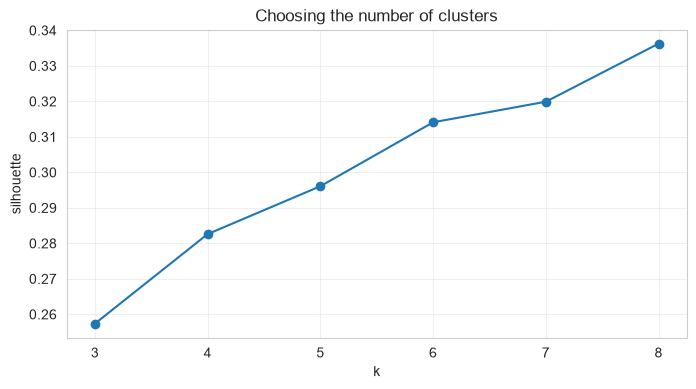


The brief asks for 4-6, so the choice is constrained to that range
regardless of what silhouette prefers.


In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("%-5s %12s" % ("k", "silhouette"))
print("-" * 20)
scores = {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(P)
    s = silhouette_score(P, km.labels_)
    scores[k] = s
    print("%-5d %12.4f" % (k, s))

plt.figure(figsize=(8, 4))
plt.plot(list(scores), list(scores.values()), marker="o")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.title("Choosing the number of clusters")
plt.grid(alpha=0.3)
plt.show()

print()
print("The brief asks for 4-6, so the choice is constrained to that range")
print("regardless of what silhouette prefers.")

In [19]:
K = 5
km = KMeans(n_clusters=K, random_state=42, n_init=10).fit(P)
products["cluster"] = km.labels_

terms = np.array(prod_vec.get_feature_names_out())
centroids = km.cluster_centers_.argsort()[:, ::-1]

for i in range(K):
    members = products[products["cluster"] == i].sort_values("reviews", ascending=False)
    print("=" * 74)
    print("CLUSTER %d  -  %d products, %d reviews"
          % (i, len(members), members["reviews"].sum()))
    print("  top terms:", ", ".join(terms[centroids[i, :8]]))
    print("-" * 74)
    for _, row in members.head(8).iterrows():
        print("   %6d  %.2f*  %s" % (row["reviews"], row["mean_rating"],
                                     row["product_name"][:60]))
    print()

CLUSTER 0  -  10 products, 3042 reviews
  top terms: home, smart, audio, speakers, smart home, amazon, assistants, automation
--------------------------------------------------------------------------
     2528  4.65*  Amazon Fire Tv
      318  4.73*  Amazon - Amazon Tap Portable Bluetooth and Wi-Fi Speaker - B
      128  4.77*  Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Special Offers - Sil
       36  4.69*  Amazon 9W PowerFast Official OEM USB Charger and Power Adapt
        9  4.78*  Kindle Dx Leather Cover, Black (fits 9.7 Display, Latest and
        7  4.29*  New Amazon Kindle Fire Hd 9w Powerfast Adapter Charger + Mic
        7  4.86*  Amazon Fire Hd 6 Standing Protective Case(4th Generation - 2
        4  5.00*  Echo (Black)

CLUSTER 1  -  10 products, 634 reviews
  top terms: readers, tablets, kindle voyage, voyage, kindle, wi fi, wi, fi
--------------------------------------------------------------------------
      368  4.60*  Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Speci

### Naming the clusters

Fill these in from the output above - the labels are a judgement call, not something
the algorithm provides. The brief's own example suggests names like "Ebook readers",
"Accessories", "Non-electronics".

In [20]:
# Edit these after reading the cluster contents printed above
CLUSTER_NAMES = {
    0: "TODO",
    1: "TODO",
    2: "TODO",
    3: "TODO",
    4: "TODO",
}

products["category"] = products["cluster"].map(CLUSTER_NAMES)

# Attach the meta-category back onto every review, for Task 3
clean_cat = clean.merge(products[["product_name", "cluster", "category"]],
                        on="product_name", how="left")

print("reviews per meta-category:")
print(clean_cat.groupby(["cluster", "category"])
      .size().rename("reviews").to_string())

clean_cat.to_csv(OUT_DIR / "reviews_clustered.csv", index=False)
print()
print("saved ../datasets/reviews_clustered.csv - this is the input for Task 3")

reviews per meta-category:
cluster  category
0.0      TODO         3042
1.0      TODO          634
2.0      TODO        22897
3.0      TODO          219
4.0      TODO         1075

saved ../datasets/reviews_clustered.csv - this is the input for Task 3


# Where this leaves us

Done, all on CPU:
- Step 0 - cleaned dataset saved
- Task 1 - classical baseline with the full metric picture
- Task 2 - products clustered into meta-categories

Still to do, and these **do** need the GPU:
- **Task 1 continued** - fine-tune DistilBERT and compare against the baseline above
- **Task 3** - generative summaries per category

And one that needs neither:
- **Task 4** - deploy the sentiment model to Hugging Face Spaces. Worth doing early;
  it is the task most likely to fail for reasons unrelated to modelling.